## Set up Gurobipy
---

In [1]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 13.0.2
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.9
Summary: Python plotting package
Home-page: 
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive

In [2]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [3]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## SALBP-2 model formulation
-----------------------------------------

When it comes to the "Simple Assembly Line Balancing Problem no. 2" there is a number of N operations with precedence relations to be performed on a fixed number of M stations. 
The operations are to be distributed among the stations in such a way that the cycle time is minimized. A simple result is illustrated in this precedence graph including station assignments.

<img src="pics/header.png" alt="Precedence graph" width="700">

### Objective function:

 0) The goal of the model is to minimize the cycle time:   $ \hspace{31mm} min \quad z = C $

### Constraints:

1) Assignment of  every  operation  only once: $\hspace{45mm} \sum_{k=1}^MS_{ik}=1  \hspace{39mm} \forall i=1,...,N $ 

2) Complying with the precedence relations: $\hspace{45mm} \sum_{k=1}^MS_{ik}\cdot k \leq \sum_{k=1}^MS_{jk}\cdot k \hspace{13mm} 
\forall(i,j) \in P$

3) Complying with the cycle time: $\hspace{63mm} \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{33mm} \forall k=1,...,M $

4) Binary decision variable: $\hspace{74mm} S_{ik} \in \{0,1\} \hspace{41mm} \forall i=1,...,N;k=1,...,M $

5) Non-negativity constraint: $\hspace{72mm} C \geq0$

---

#### Indices and sets
$i,j\in(1,..,N) \hspace{15mm}$  operations                      

$k\in(1,..,M) \hspace{17mm}$ stations                         

$(i,j)\in P \hspace{26mm}$ set of precedence relations     

#### Parameters
$t_i \hspace{40mm}$  Processing time of operation i 

#### Decision variables
$S_{ik} \hspace{38mm}$  Binary variable             

$C \hspace{41mm}$  Cycle time 

------------------------------------------------------------

### Create the model.
---

Initialize the model m with Gurobi as optimizer.

In [4]:
# Model
m = gp.Model("MILP")


# Surpress Output
m.setParam("OutputFlag", 0)
m.setParam("MIPgap", 0)

Restricted license - for non-production use only - expires 2027-11-29


### Case study data:
---

#### Number of stations: 6 

#### Operations:
| Operation | processing time| direct predecessors
|:-----------|:----------------|:------------------|
| 1 | 5.5 |   |  
| 2 | 7.4 |   | 
| 3 | 1.3 | 1   | 
| 4 | 9 | 1, 2   | 
| 5 | 2.6 | 3  | 
| 6 | 4.6 | 4, 7  | 
| 7 | 8 | 2  | 
| 8 | 4.5 | 5, 6  | 
| 9 | 3 | 7, 6  | 


### Sets and parameters
---

Insert the parameters: Operations i, Stations k, N, M and the PrecRelations as arrays.

In [5]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations = [1,2,3,4,5,6]

N = len(Operations)
M = len(Stations)

PrecRelations = [ [1, 3], [1, 4], [2, 4], [2, 7], [3, 5], [4, 6], [7, 6], [7, 9], [5, 8], [6, 8], [6, 9] ]

Insert the times needed for the single operations $t_i$ as an array.

In [6]:
t = [5.5, 7.4, 1.3, 9, 2.6, 4.6, 8, 4.5, 3]

### Decision variables
---

Define the decision variables including the non-negativity and binary constraints:

**4) Binary decision variable**: 
The binary decision variable $S_{ik}$ is 1 if an operation i is assigned to station k, otherwise 0.

In [7]:
S = m.addVars(N, M, vtype=GRB.BINARY, name="S");

**5)  Non-negativity constraint**:  The cycle time C can't be negative.

In [8]:
C = m.addVar(lb=0, name="C");

**5)  Auxiliary variable to break symmetry**:  Prefer assignment to lower station number in case of multiple solutions

In [9]:
symBreak = m.addVar(lb=0, name="symBreak");

### Objective function 
---

Define the objective value to minimize the cycle time.

Note: You can ignore the additional term "symBreak". We just want to make sure that everyone gets the same results when there is more than one possible solutions. 

*Be careful though! Because of this addition the optimal cycle time differs from the objective value.*

In [10]:
m.setObjective(C + symBreak, GRB.MINIMIZE)

### Constraints
---


**1) Assign every operation only once**: Each operation may be assigned only once. The sum of the number of assignments of each operation across all stations must therefore add up to one. 

$ \qquad \sum_{k=1}^{M} S_{ik} = 1 \hspace{40mm} \forall i=1,...,N$

In [11]:
m.addConstrs((quicksum(S[i, k] for k in range(M)) == 1 for i in range(N)), name="allOperCon");

**2) Complying the precedence relations**: An operation j may only begin when the predecessor operation i has been completed and can therefore not be processed on a station in front of i's processing station.

$ \qquad \sum_{k=1}^{M} S_{ik}\cdot k \leq \sum_{k=1}^{M} S_{jk}\cdot k \hspace{25mm}  \forall (i,j) \in P $

In [12]:
m.addConstrs((quicksum(S[i, k]*k for k in range(M)) <= quicksum(S[j, k]*k for k in range(M))
              for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="precRelCon");

**3) Complying the cycle time**:
The cycle time must be smaller than the sum of the processing times of all operations carried out on a station k.

$ \qquad  \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{34mm} \forall k=1,...,M $




In [13]:
m.addConstrs((quicksum(S[i, k]*t[i] for i in range(N)) <= C for k in range(M)), name="cycleTimeCon");

**4) Symmetry breaking constraint**

In [14]:
m.addConstr(symBreak >= quicksum(S[i, k]*k*(0.1**(i+1)) for k in range(M) for i in range(N)), name="symBreakCon");

### Solve and display results
---

Get the whole model m displayed.

In [15]:
m

<gurobi.Model Continuous instance MILP: 0 constrs, 0 vars, Parameter changes: MIPGap=0.0, OutputFlag=0>

Run the model m.

In [16]:
# Solve
m.optimize()


### Get the results displayed.

Print out the objective value C as well as the termination status and the primal status.

In [17]:
# Print results
if m.status == GRB.OPTIMAL:
    print("Objective value: ", m.objVal)
    print("Cycle Time C: ", C.x)
    print("Solution:")
    for i in range(N):
        for k in range(M):
            if S[i, k].x > 0.5:
                print("Operation ", i+1, " is assigned to station ", k+1)
else:
    print("No solution found")

Objective value:  9.010244355
Cycle Time C:  9.0
Solution:
Operation  1  is assigned to station  1
Operation  2  is assigned to station  2
Operation  3  is assigned to station  1
Operation  4  is assigned to station  3
Operation  5  is assigned to station  5
Operation  6  is assigned to station  5
Operation  7  is assigned to station  4
Operation  8  is assigned to station  6
Operation  9  is assigned to station  6


Now get displayed where each operation is performed, there might be other solutions as well leading to the same objective function value.

Want to add a nice visualization?

# Model extension — Budget-constrained SALBP-2 with Human, Cobot & Humanoid resources
-----------------------------------------

The original SALBP-2 model above stays **unchanged**. This section *extends* it: every operation can now be carried out by one of three resource types — a **human**, a **cobot**, or a **humanoid robot** — each with its own processing time and cost. Each station is equipped with one resource type, and the total resource cost must respect an investment **budget $B$**. The objective is still to **minimise the cycle time $C$** — cost only ever enters as a *constraint*, never in the objective, so this remains a genuine SALBP-2. Sweeping $B$ traces the **time–cost (Pareto) frontier**, which is the central study of this project.

### Extended model formulation

**Additional sets**

$r\in\{\text{Human},\ \text{Cobot},\ \text{Humanoid}\}\hspace{15mm}$ resource types

**Additional parameters**

$t_{ir}\hspace{40mm}$ processing time of operation $i$ with resource $r$

$H\hspace{43mm}$ planning horizon / utilisation (h / year)

$K_r=\text{invest}_r+\text{oper}_r\cdot H\hspace{18mm}$ total cost of resource $r$ over the horizon

$B\hspace{43mm}$ investment budget

**Additional decision variables**

$Y_{kr}\in\{0,1\}\hspace{32mm}$ 1 if station $k$ is equipped with resource $r$

$S_{ikr}\in\{0,1\}\hspace{31mm}$ 1 if operation $i$ runs at station $k$ using resource $r$

**Objective** (unchanged): $\hspace{20mm}\min\quad z=C$

**Constraints**

0) Assign every operation once: $\hspace{20mm}\sum_{k}\sum_{r}S_{ikr}=1\hspace{20mm}\forall i$

1) One resource per station: $\hspace{23mm}\sum_{r}Y_{kr}=1\hspace{27mm}\forall k$

2) Coupling task $\to$ equipped resource: $\hspace{6mm}S_{ikr}\le Y_{kr}\hspace{27mm}\forall i,k,r$

3) Cycle time (resource-dependent): $\hspace{10mm}\sum_{i}\sum_{r}S_{ikr}\,t_{ir}\le C\hspace{18mm}\forall k$

4) Precedence relations: $\hspace{27mm}\sum_{k}\sum_{r}S_{ikr}\,k\le\sum_{k}\sum_{r}S_{jkr}\,k\hspace{8mm}\forall(i,j)\in P$

5) Budget: $\hspace{47mm}\sum_{k}\sum_{r}K_r\,Y_{kr}\le B$

*Note:* constraint (1) equips every station (as in the presentation). Since the optimal balance uses all $M$ stations here, replacing it by $\sum_r Y_{kr}\le 1$ (pay only for stations that carry work) yields the same result — but it is the cleaner choice if empty stations can occur.

---

### Resource data — time & cost assumptions
---
The original processing times $t_i$ are reused as the **human** baseline; cobot and humanoid times follow from per-resource speed factors (robots are faster on standard, repetitive tasks but slower on delicate ones). All of these are modelling assumptions you can replace with real data.

In [18]:
# Resource types ---------------------------------------------------------------
Resources = ["Human", "Cobot", "Humanoid"]
R = len(Resources)

# Processing times t(i,r): the original t_i are the HUMAN baseline; cobot/humanoid
# times follow from per-resource speed factors. Tasks flagged as "delicate"
# (fine/precision work) are faster for humans and slower for robots.
delicate_ops = {3, 8}                               # 1-indexed operations
speed = {"Human":    (1.00, 1.00),                  # (standard, delicate) factor
         "Cobot":    (0.80, 1.70),
         "Humanoid": (0.60, 1.40)}

t_r = [[round(t[i] * speed[Resources[r]][1 if (i + 1) in delicate_ops else 0], 3)
        for r in range(R)] for i in range(N)]

df_times = pd.DataFrame(t_r, columns=Resources,
                        index=[f"op {i+1}{' *' if (i+1) in delicate_ops else ''}" for i in range(N)])
print("Resource-dependent processing times t(i,r)   (* = delicate task):")
print(df_times.to_string())

Resource-dependent processing times t(i,r)   (* = delicate task):
        Human  Cobot  Humanoid
op 1      5.5   4.40      3.30
op 2      7.4   5.92      4.44
op 3 *    1.3   2.21      1.82
op 4      9.0   7.20      5.40
op 5      2.6   2.08      1.56
op 6      4.6   3.68      2.76
op 7      8.0   6.40      4.80
op 8 *    4.5   7.65      6.30
op 9      3.0   2.40      1.80


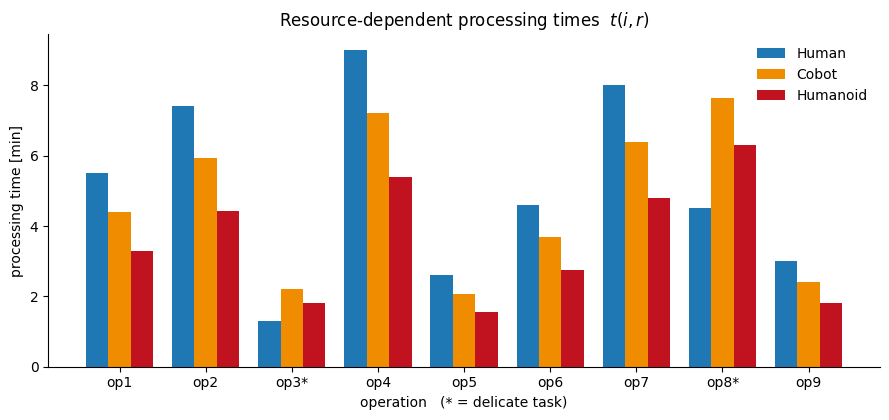

In [19]:
# Visualise which resource is fastest on which task ---------------------------
col = {"Human": "#1f77b4", "Cobot": "#f08c00", "Humanoid": "#c1121f"}

fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(N); w = 0.26
for r in range(R):
    ax.bar(x + (r - 1) * w, [t_r[i][r] for i in range(N)], w,
           label=Resources[r], color=col[Resources[r]])
ax.set_xticks(x)
ax.set_xticklabels([f"op{i+1}{'*' if (i+1) in delicate_ops else ''}" for i in range(N)])
ax.set_xlabel("operation   (* = delicate task)")
ax.set_ylabel("processing time [min]")
ax.set_title("Resource-dependent processing times  $t(i,r)$")
ax.legend(frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Cost data & capital budgeting
---
Each resource carries a one-off **investment** plus an hourly **operating** cost. Over a horizon $H$ (hours per year) the total cost is $K_r=\text{invest}_r+\text{oper}_r\cdot H$. This investment-plus-operating split is exactly what distinguishes the model from a pure operating-cost cap: a humanoid is *expensive to buy* but *cheap to run*.

In [20]:
# Cost assumptions (from presentation #2) -------------------------------------
invest = {"Human": 0,  "Cobot": 50_000, "Humanoid": 200_000}   # one-off investment [EUR]
oper   = {"Human": 35, "Cobot": 10,     "Humanoid": 5}         # operating cost [EUR/h]
H = 2000                                                        # planning horizon [h/year]

def K_of(H):
    """Total cost per resource over the horizon:  K(r) = investment + operating * H."""
    return [invest[Resources[r]] + oper[Resources[r]] * H for r in range(R)]

K = K_of(H)
B_min = M * min(K)        # cheapest feasible line (every station on the cheapest resource)
B_max = M * max(K)        # most expensive line  (every station a humanoid)
print("K(r) [EUR over horizon]:", {Resources[r]: K[r] for r in range(R)})
print(f"Budget range:  B_min = {B_min:,} EUR   ...   B_max = {B_max:,} EUR")

K(r) [EUR over horizon]: {'Human': 70000, 'Cobot': 70000, 'Humanoid': 210000}
Budget range:  B_min = 420,000 EUR   ...   B_max = 1,260,000 EUR


### Build & solve the extended model
---
The model is wrapped in a function `solve_extended(B, H, allowed)` so it can be re-solved for many budget levels (for the frontier), for different horizons $H$ (for the sensitivity analysis), and restricted to a subset of resources (e.g. *human only* for a baseline). Its structure — decision variables → objective → constraints → solve — mirrors the base model above.

In [21]:
def solve_extended(B, H=2000, allowed=None, verbose=False):
    """Budget-constrained SALBP-2 with heterogeneous resources (human / cobot / humanoid).

    B        budget over the planning horizon
    H        planning horizon [h/year] (enters the resource cost K(r))
    allowed  optional subset of resource indices that may be used (e.g. {0} = human only)
    Returns the optimal cycle time together with the resource/task assignment.
    """
    allowed = set(range(R)) if allowed is None else set(allowed)
    Kr = K_of(H)

    mE = gp.Model("MILP_extended")
    mE.setParam("OutputFlag", 0)
    mE.setParam("MIPgap", 0)

    Y  = mE.addVars(M, R, vtype=GRB.BINARY, name="Y")        # Y[k,r] : station k equipped with resource r
    Sr = mE.addVars(N, M, R, vtype=GRB.BINARY, name="S")     # S[i,k,r]: operation i at station k using resource r
    Cb = mE.addVar(lb=0, name="C")                           # cycle time

    mE.setObjective(Cb, GRB.MINIMIZE)

    # 0) assign every operation exactly once (over stations AND resources)
    mE.addConstrs((quicksum(Sr[i, k, r] for k in range(M) for r in range(R)) == 1
                   for i in range(N)), name="assignCon")
    # 1) exactly one resource per station
    mE.addConstrs((quicksum(Y[k, r] for r in range(R)) == 1 for k in range(M)), name="oneResCon")
    # 2) a task may only use the resource its station is equipped with
    mE.addConstrs((Sr[i, k, r] <= Y[k, r]
                   for i in range(N) for k in range(M) for r in range(R)), name="couplingCon")
    # 3) cycle time with resource-dependent processing times
    mE.addConstrs((quicksum(Sr[i, k, r] * t_r[i][r] for i in range(N) for r in range(R)) <= Cb
                   for k in range(M)), name="cycleTimeCon")
    # 4) precedence relations (station order)
    mE.addConstrs((quicksum(Sr[i, k, r] * k for k in range(M) for r in range(R)) <=
                   quicksum(Sr[j, k, r] * k for k in range(M) for r in range(R))
                   for i in range(N) for j in range(N) if [i + 1, j + 1] in PrecRelations),
                  name="precRelCon")
    # 5) budget
    mE.addConstr(quicksum(Kr[r] * Y[k, r] for k in range(M) for r in range(R)) <= B, name="budgetCon")
    # optional: restrict to a subset of resources
    for r in range(R):
        if r not in allowed:
            mE.addConstrs((Y[k, r] == 0 for k in range(M)), name=f"forbidRes{r}")

    mE.optimize()
    if mE.status != GRB.OPTIMAL:
        return {"B": B, "status": mE.status, "C": None}

    resource_of = {k: next(r for r in range(R) if Y[k, r].x > 0.5) for k in range(M)}
    equip  = {k: Resources[resource_of[k]] for k in range(M)}
    assign = {k: [i + 1 for i in range(N) for r in range(R) if Sr[i, k, r].x > 0.5] for k in range(M)}
    counts = [sum(resource_of[k] == r for k in range(M)) for r in range(R)]
    cost   = int(sum(Kr[r] * round(Y[k, r].x) for k in range(M) for r in range(R)))

    if verbose:
        print(f"Budget B = {B:,} EUR   ->   cycle time C = {round(Cb.x, 3)}   (resource cost = {cost:,} EUR)")
        for k in range(M):
            ops  = assign[k]
            load = round(sum(t_r[i - 1][resource_of[k]] for i in ops), 3)
            print(f"  Station {k+1}: {equip[k]:9s}  ops {ops}  (load {load})")

    return {"B": B, "status": int(mE.status), "C": round(Cb.x, 3),
            "equip": equip, "assign": assign, "resource_of": resource_of,
            "counts": counts, "cost": cost, "nHumanoid": counts[2]}

Solve once for an example budget and print the resource allocation per station.

In [22]:
B_example = 700_000
sol = solve_extended(B_example, verbose=True)

Budget B = 700,000 EUR   ->   cycle time C = 6.61   (resource cost = 700,000 EUR)
  Station 1: Cobot      ops [1, 3]  (load 6.61)
  Station 2: Cobot      ops [2]  (load 5.92)
  Station 3: Humanoid   ops [4]  (load 5.4)
  Station 4: Cobot      ops [7]  (load 6.4)
  Station 5: Humanoid   ops [5, 6, 9]  (load 6.12)
  Station 6: Human      ops [8]  (load 4.5)


### Visualization 1 — resource allocation & station loads
---
Each bar is one station, coloured by the resource it is equipped with; the numbers are the operations assigned to it, drawn to scale by their resource-dependent processing time. The dashed line marks the resulting cycle time $C$ (the busiest station).

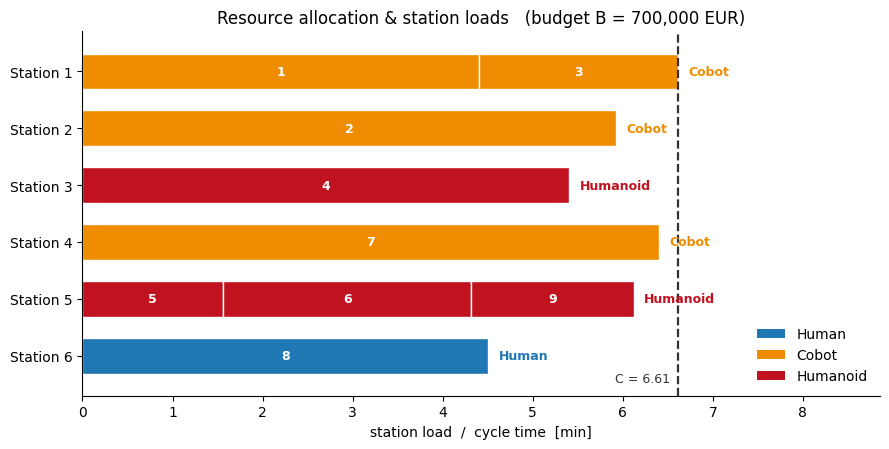

In [23]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 4.6))
for k in range(M):
    r = sol["resource_of"][k]
    left = 0
    for op in sol["assign"][k]:
        w = t_r[op - 1][r]
        ax.barh(k, w, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
        ax.text(left + w / 2, k, str(op), ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
        left += w
    ax.text(left + 0.12, k, sol["equip"][k], va="center",
            color=col[Resources[r]], fontsize=9, fontweight="bold")

ax.axvline(sol["C"], ls="--", lw=1.6, color="#333")
ax.set_yticks(range(M))
ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
ax.set_ylim(-0.7, 5.7)
ax.invert_yaxis()
ax.text(sol["C"], 5.4, f"C = {sol['C']}  ", color="#333", fontsize=9, va="center", ha="right")
ax.set_xlim(0, sol["C"] * 1.34)
ax.set_xlabel("station load  /  cycle time  [min]")
ax.set_title(f"Resource allocation & station loads   (budget B = {B_example:,} EUR)")
ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
          loc="lower right", frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 2 — the time–cost frontier
---
We iterate over budget levels and record the minimum achievable cycle time for each — the core question of the project: **how much cycle time is bought per euro of budget.** As a reference, the **human-only baseline** (the original single-mode SALBP-2) is also computed: it shows how much the heterogeneous resources help even before any extra budget is spent.

In [24]:
# Human-only baseline = the original single-mode SALBP-2 (reference point)
C_baseline = solve_extended(10**9, allowed={0})["C"]
print(f"Human-only baseline cycle time (all stations human): C = {C_baseline}\n")

# Sweep the budget and record the minimum achievable cycle time
budgets  = list(range(B_min, B_max + 1, 20_000))
frontier = [solve_extended(B) for B in budgets]

df_frontier = pd.DataFrame({
    "Budget B [EUR]":      [f["B"] for f in frontier],
    "min. cycle time C":   [f["C"] for f in frontier],
    "# humanoid stations": [f["nHumanoid"] for f in frontier],
})
print(df_frontier.iloc[::3].to_string(index=False))

Human-only baseline cycle time (all stations human): C = 9.0

 Budget B [EUR]  min. cycle time C  # humanoid stations
         420000               7.20                    0
         480000               7.20                    0
         540000               7.20                    0
         600000               6.96                    1
         660000               6.96                    1
         720000               6.61                    2
         780000               6.61                    2
         840000               6.36                    3
         900000               6.36                    3
         960000               6.36                    3
        1020000               6.08                    4
        1080000               6.08                    4
        1140000               6.00                    5
        1200000               6.00                    5
        1260000               6.00                    5


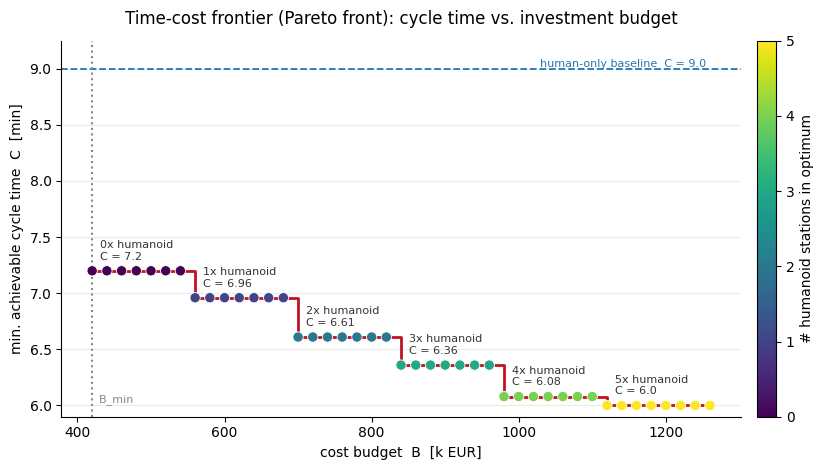

In [25]:
xb = [f["B"] / 1000 for f in frontier]
yc = [f["C"] for f in frontier]
nh = [f["nHumanoid"] for f in frontier]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhline(C_baseline, ls="--", color="#1f77b4", lw=1.3)
ax.text(B_max / 1000, C_baseline, f"human-only baseline  C = {C_baseline} ",
        color="#1f77b4", va="bottom", ha="right", fontsize=8)
ax.step(xb, yc, where="post", color="#c1121f", lw=2, zorder=2)
sc = ax.scatter(xb, yc, c=nh, cmap="viridis", s=55, zorder=3,
                edgecolor="white", linewidth=0.6)
cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("# humanoid stations in optimum")

seen = set()
for f in frontier:                       # annotate each new (cheapest) plateau
    if f["C"] not in seen:
        seen.add(f["C"])
        ax.annotate(f"{f['nHumanoid']}x humanoid\nC = {f['C']}",
                    (f["B"] / 1000, f["C"]), textcoords="offset points",
                    xytext=(6, 8), fontsize=8, color="#333")
ax.axvline(B_min / 1000, ls=":", color="#888")
ax.text(B_min / 1000, min(yc), "  B_min", color="#888", va="bottom", fontsize=8)
ax.set_ylim(min(yc) - 0.1, C_baseline + 0.25)
ax.set_xlabel("cost budget  B  [k EUR]")
ax.set_ylabel("min. achievable cycle time  C  [min]")
ax.set_title("Time-cost frontier (Pareto front): cycle time vs. investment budget", pad=12)
ax.grid(axis="y", alpha=0.25)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 3 — marginal value of budget
---
Reading the frontier as an investment decision: each step down the frontier adds one humanoid station (here +140k€). The table and chart show how much cycle time each extra step actually buys — the returns diminish sharply, which is exactly the argument for *where to stop investing*.

 from C  to C  dC [min]  extra budget [EUR]  dC per 100k EUR
   7.20  6.96      0.24              140000            0.171
   6.96  6.61      0.35              140000            0.250
   6.61  6.36      0.25              140000            0.179
   6.36  6.08      0.28              140000            0.200
   6.08  6.00      0.08              140000            0.057


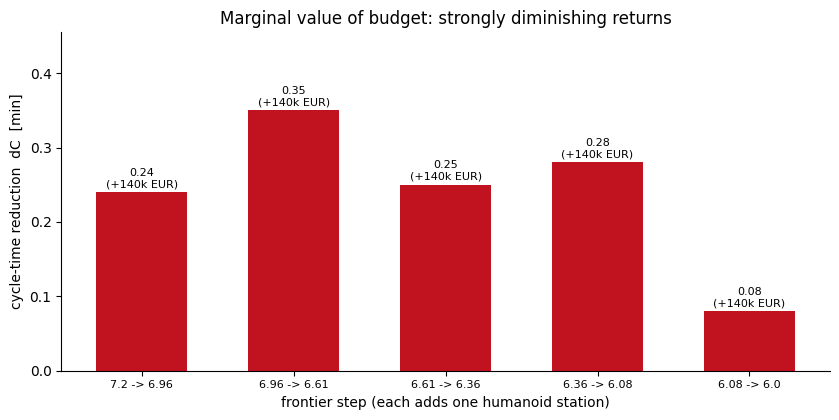

In [26]:
# Cheapest budget achieving each distinct cycle time = the Pareto-efficient "knees"
knees = {}
for f in frontier:
    if f["C"] not in knees:
        knees[f["C"]] = f
knees = sorted(knees.values(), key=lambda f: -f["C"])      # cheap/slow -> expensive/fast

rows = []
for a, b in zip(knees[:-1], knees[1:]):
    rows.append({"from C": a["C"], "to C": b["C"],
                 "dC [min]": round(a["C"] - b["C"], 3),
                 "extra budget [EUR]": b["cost"] - a["cost"],
                 "dC per 100k EUR": round((a["C"] - b["C"]) / ((b["cost"] - a["cost"]) / 1e5), 3)})
df_marg = pd.DataFrame(rows)
print(df_marg.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.3))
labels = [f"{r['from C']} -> {r['to C']}" for r in rows]
dCs = [r["dC [min]"] for r in rows]
ax.bar(range(len(rows)), dCs, 0.6, color="#c1121f")
for j, r in enumerate(rows):
    ax.text(j, r["dC [min]"] + 0.004,
            f"{r['dC [min]']}\n(+{r['extra budget [EUR]']//1000}k EUR)",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(rows))); ax.set_xticklabels(labels, fontsize=8)
ax.set_xlabel("frontier step (each adds one humanoid station)")
ax.set_ylabel("cycle-time reduction  dC  [min]")
ax.set_title("Marginal value of budget: strongly diminishing returns")
ax.set_ylim(0, max(dCs) * 1.3)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 4 — how the optimal resource mix shifts
---
The same efficient configurations, seen from the *equipment* side: as the budget grows, the optimum systematically **replaces cobots with humanoids**, while one human station is kept throughout for the delicate tasks (op 3, op 8). This is the substitution mechanism behind the frontier.

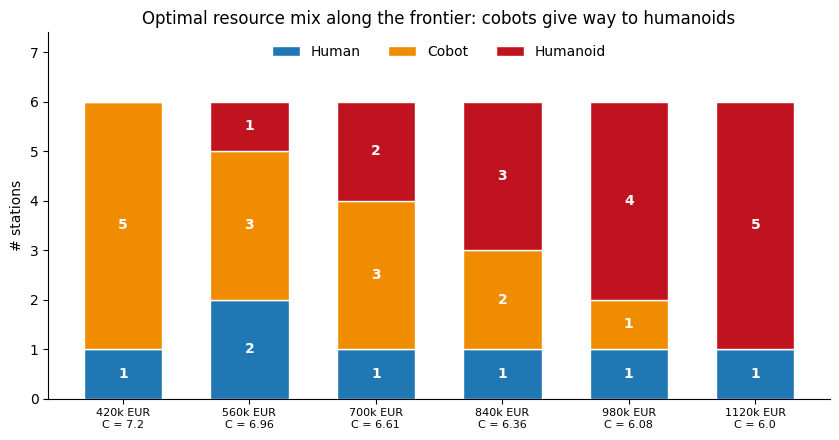

In [27]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
xk = np.arange(len(knees)); bottom = np.zeros(len(knees))
for r in range(R):
    vals = [k["counts"][r] for k in knees]
    ax.bar(xk, vals, 0.62, bottom=bottom, label=Resources[r],
           color=col[Resources[r]], edgecolor="white")
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(xk[j], bottom[j] + v / 2, str(v), ha="center", va="center",
                    color="white", fontweight="bold")
    bottom = bottom + vals
ax.set_xticks(xk)
ax.set_xticklabels([f"{k['cost']//1000}k EUR\nC = {k['C']}" for k in knees], fontsize=8)
ax.set_ylabel("# stations")
ax.set_ylim(0, M + 1.4)
ax.set_title("Optimal resource mix along the frontier: cobots give way to humanoids")
ax.legend(frameon=False, ncol=3, loc="upper center")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 5 — capital-budgeting view: the role of utilisation $H$
---
This is the heart of the project's contribution. Because $K_r=\text{invest}_r+\text{oper}_r\cdot H$, **which resource is cheapest depends on how intensively the line runs.** At low utilisation the one-off investment dominates (humanoids look expensive); at high utilisation the low operating cost dominates (humanoids become cheap). The break-even horizons below mark exactly where each resource overtakes another — something a pure operating-cost budget (as in Battaïa et al. 2025) cannot express.

Human = Cobot     at H = 2,000 h/year
Human = Humanoid  at H = 6,667 h/year
Cobot = Humanoid  at H = 30,000 h/year


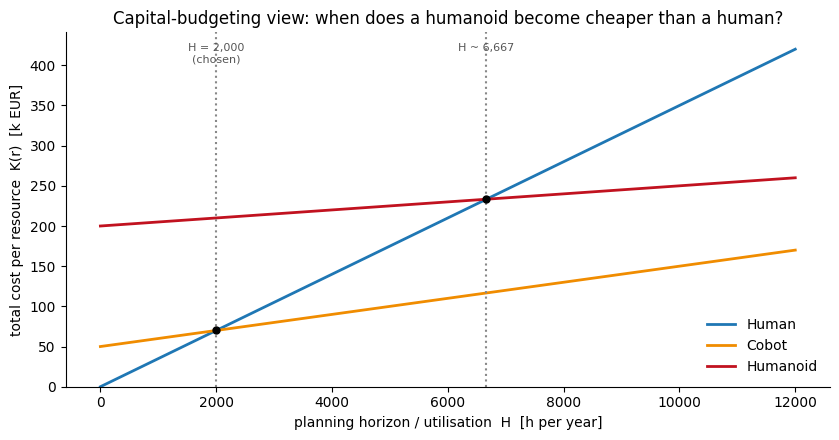

In [28]:
# Break-even utilisations where two resources cost the same over the horizon
be_hc = (invest["Cobot"]    - invest["Human"]) / (oper["Human"] - oper["Cobot"])
be_hh = (invest["Humanoid"] - invest["Human"]) / (oper["Human"] - oper["Humanoid"])
be_ch = (invest["Humanoid"] - invest["Cobot"]) / (oper["Cobot"] - oper["Humanoid"])
print(f"Human = Cobot     at H = {be_hc:,.0f} h/year")
print(f"Human = Humanoid  at H = {be_hh:,.0f} h/year")
print(f"Cobot = Humanoid  at H = {be_ch:,.0f} h/year")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
Hs = np.linspace(0, 12000, 200)
for r in range(R):
    ax.plot(Hs, [(invest[Resources[r]] + oper[Resources[r]] * h) / 1000 for h in Hs],
            label=Resources[r], color=col[Resources[r]], lw=2)
trans = ax.get_xaxis_transform()
for Hb, txt in [(be_hc, f"H = {be_hc:,.0f}\n(chosen)"), (be_hh, f"H ~ {be_hh:,.0f}")]:
    ax.axvline(Hb, ls=":", color="#888")
    ax.text(Hb, 0.97, txt, transform=trans, fontsize=8, ha="center", va="top", color="#555")
ax.scatter([be_hc, be_hh],
           [(invest["Human"] + oper["Human"] * be_hc) / 1000,
            (invest["Human"] + oper["Human"] * be_hh) / 1000],
           color="k", zorder=5, s=25)
ax.set_xlabel("planning horizon / utilisation  H  [h per year]")
ax.set_ylabel("total cost per resource  K(r)  [k EUR]")
ax.set_title("Capital-budgeting view: when does a humanoid become cheaper than a human?")
ax.legend(frameon=False, loc="lower right")
ax.set_ylim(bottom=0)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Reading the results — managerial & academic takeaways
---
- **Heterogeneity helps before any extra spend.** The human-only baseline is $C = 9.0$; at the *minimum* budget the heterogeneous line already reaches $C = 7.2$ by mixing cobots (standard tasks) and humans (delicate tasks) at the same cost.
- **The frontier is a step function.** Cycle time only improves when the budget crosses the threshold to afford another humanoid: $7.2 \to 6.96 \to 6.61 \to 6.36 \to 6.08 \to 6.0$.
- **Diminishing returns.** The first humanoids buy real time; the **5th humanoid costs +140k€ for only 0.08 min**. A cost-conscious planner stops around 3 humanoids ($C = 6.36$ at 840k€).
- **Delicate tasks stay human** at every budget level — the model recovers the intuitive division of labour on its own.
- **Utilisation drives the decision.** With the chosen $H = 2000\,$h humanoids are the dearest option; above $H \approx 6{,}667\,$h a humanoid becomes cheaper than a human, so on a heavily-utilised line the optimum tilts strongly toward humanoids.

**Differentiation from Battaïa et al. (2025).** The humanoid is modelled as its *own* hardware resource (not a collaborative mode); cost is split into **investment + operating** over a horizon $H$ (capital budgeting, not just an operating-cost cap); the budget is a **hard constraint**, never in the objective; and there is **no scheduling/setup layer** — which keeps the model light enough to trace the full frontier and to run the horizon-sensitivity study above.

### Interactive — budget slider driving Visualization 1
---
Drag the **budget slider** to re-solve the model in real time: the chart is exactly *Visualization 1* (station loads coloured by resource), redrawn for the chosen budget. Watch the humanoids appear and the cycle time $C$ fall as the budget grows. *(Requires `ipywidgets`, which ships with JupyterLab / Notebook — run the cell, then move the slider. The static image shown is the preview at B = 700,000 €.)*

In [29]:
from matplotlib.patches import Patch

def plot_station_loads(B):
    """Visualization 1, redrawn for an arbitrary budget B."""
    sol = solve_extended(int(B))
    fig, ax = plt.subplots(figsize=(9, 4.6))
    for k in range(M):
        r = sol["resource_of"][k]
        left = 0
        for op in sol["assign"][k]:
            w = t_r[op - 1][r]
            ax.barh(k, w, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
            ax.text(left + w / 2, k, str(op), ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
            left += w
        ax.text(left + 0.12, k, sol["equip"][k], va="center",
                color=col[Resources[r]], fontsize=9, fontweight="bold")
    ax.axvline(sol["C"], ls="--", lw=1.6, color="#333")
    ax.set_yticks(range(M)); ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
    ax.set_ylim(-0.7, 5.7); ax.invert_yaxis()
    ax.text(sol["C"], 5.4, f"C = {sol['C']}  ", color="#333", fontsize=9, va="center", ha="right")
    ax.set_xlim(0, max(sol["C"], 1) * 1.34)
    ax.set_xlabel("station load  /  cycle time  [min]")
    ax.set_title(f"Resource allocation & station loads   "
                 f"(B = {int(B):,} EUR,  C = {sol['C']},  {sol['nHumanoid']} humanoid(s))")
    ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
              loc="lower right", frameon=False)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    plt.tight_layout(); plt.show()

# Interactive slider (falls back to a static chart if ipywidgets is unavailable)
try:
    import ipywidgets as widgets
    widgets.interact(
        plot_station_loads,
        B=widgets.IntSlider(value=B_example, min=B_min, max=B_max, step=20_000,
                            description="Budget B [EUR]:", continuous_update=False,
                            readout_format=",d", style={"description_width": "initial"},
                            layout=widgets.Layout(width="640px")))
except ModuleNotFoundError:
    print("ipywidgets not available - showing a static chart instead "
          "(install with: pip install ipywidgets)")
    plot_station_loads(B_example)

interactive(children=(IntSlider(value=700000, continuous_update=False, description='Budget B [EUR]:', layout=L…